## Packages

In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout, SimpleRNN
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

## Generate a random walk

In [2]:
# generate a random walk
def random_walk(steps, scale = 1):
    w = np.zeros(steps)
    for x in range(1,steps):
        w[x] = w[x-1] + scale * np.random.normal()
    return(w)

In [3]:
time_steps = 5000
data = pd.DataFrame({'x' : range(time_steps), 
    'y' : np.arange(time_steps) ** (1/2) + random_walk(time_steps) })
data = data.assign(z = np.log(data.x+1) + 0.3 * data.y)
data_mat = np.array(data)

In [4]:
data

,x,y,z
0,0,0.000000,0.000000
1,1,0.377305,0.806339
2,2,-0.236003,1.027811
3,3,1.184805,1.741736
4,4,2.485614,2.355122
...,...,...,...
4995,4995,50.576857,23.689450
4996,4996,50.962429,23.805322
4997,4997,53.186959,24.472881
4998,4998,53.061005,24.435295


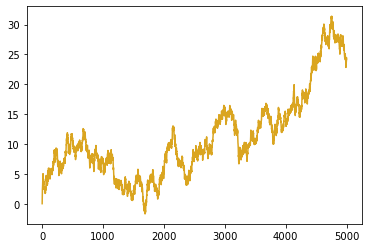

In [5]:
plt.plot(data_mat[:,0], data_mat[:,2], c = 'goldenrod')
plt.margins(0.05)

## Splitting Data, and put them in the right format for an RNN

In [6]:
# sliding time windows samples
samples = list()
target = list()
length = 50

# step over the 5,000 in jumps of length
for i in range(time_steps - length):
  # grab from i to i + length
    sample = data_mat[i:i+length,:2]
    outcome = data_mat[i+length,2]
    target.append(outcome)
    samples.append(sample)

# split out a test set
test_size = 1000
x_test_mat = np.dstack(samples[-test_size:])
x_test_3d_final = np.moveaxis(x_test_mat, [0, 1, 2], [1, 2, 0] )

In [7]:
# The RNN needs data with the format of [samples, time steps, features].
# Here, we have N samples, 50 time steps per sample, and 2 features
data_mat_stacked = np.dstack(samples[:-test_size])
data_mat_3d_final = np.moveaxis(data_mat_stacked, [0, 1, 2], [1, 2, 0] )

# and fix up the target
target_arr = np.array(target[:-test_size])

## Build the RNN model

In [13]:
model = Sequential()
model.add(SimpleRNN(128, input_shape = (data_mat_3d_final.shape[1],
    data_mat_3d_final.shape[2]), activation = 'relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation = 'relu'))
model.add(Dropout(0.1))
model.add(Dense(16, activation = 'relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='linear'))

In [14]:
# monitor validation progress
early = EarlyStopping(monitor = "val_loss", mode = "min", patience = 7)
callbacks_list = [early]
    
model.compile(loss = 'mean_squared_error',
              optimizer = 'adam',
              metrics = ['mse'])

In [15]:
# and train the model
history = model.fit(data_mat_3d_final, target_arr, 
    epochs=50, batch_size=25, verbose=2, 
    validation_split = 0.20,
    callbacks = callbacks_list)

Epoch 1/50
127/127 - 3s - loss: 1359.8223 - mse: 1359.8223 - val_loss: 151.9635 - val_mse: 151.9635
Epoch 2/50
127/127 - 1s - loss: 82.0420 - mse: 82.0420 - val_loss: 67.9704 - val_mse: 67.9704
Epoch 3/50
127/127 - 1s - loss: 57.6194 - mse: 57.6194 - val_loss: 7.3785 - val_mse: 7.3785
Epoch 4/50
127/127 - 1s - loss: 47.3962 - mse: 47.3962 - val_loss: 7.1406 - val_mse: 7.1406
Epoch 5/50
127/127 - 1s - loss: 40.1902 - mse: 40.1902 - val_loss: 3.7579 - val_mse: 3.7579
Epoch 6/50
127/127 - 1s - loss: 34.8093 - mse: 34.8093 - val_loss: 5.3461 - val_mse: 5.3461
Epoch 7/50
127/127 - 1s - loss: 37.3793 - mse: 37.3793 - val_loss: 4.7730 - val_mse: 4.7730
Epoch 8/50
127/127 - 1s - loss: 30.5420 - mse: 30.5420 - val_loss: 4.8330 - val_mse: 4.8330
Epoch 9/50
127/127 - 1s - loss: 29.8223 - mse: 29.8223 - val_loss: 9.3340 - val_mse: 9.3340
Epoch 10/50
127/127 - 1s - loss: 27.3594 - mse: 27.3594 - val_loss: 4.3159 - val_mse: 4.3159
Epoch 11/50
127/127 - 1s - loss: 24.1354 - mse: 24.1354 - val_loss: 3

## Some analysis

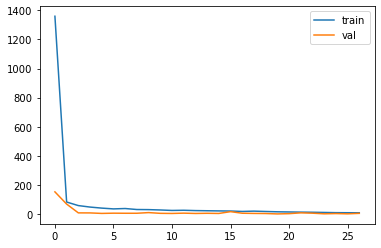

In [16]:
# plot history
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()

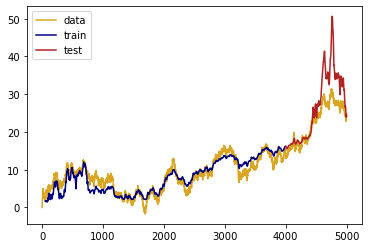

In [17]:
# get predictions
train_predictions = model.predict(data_mat_3d_final)
test_predictions = model.predict(x_test_3d_final)

# plot predictions vs actual
plt.plot(data['x'], 
    data['z'], c = 'goldenrod', label = 'data')
plt.plot(data.iloc[(length):-test_size]['x'], 
    train_predictions, c = 'navy', label = 'train')
plt.plot(data.iloc[-test_size:]['x'], 
    test_predictions, c = 'firebrick', label = 'test')
plt.legend(loc='best')
plt.show()